In [ ]:
!pip install xgboost shap statsmodels linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 3.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import shap
from scipy import stats
import warnings
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
from linearmodels.panel import PanelOLS, RandomEffects
# Import VIF for multicollinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor
warnings.filterwarnings('ignore')

In [ ]:
# Load all sheets into a dictionary
df_dict = pd.read_excel("/content/RM project - Credit Risk (1).xlsx", sheet_name=None)

# Get all sheet names
sheet_names = list(df_dict.keys())

# Exclude the last one
sheet_names_to_merge = sheet_names[:-1]

# Read and combine them
df = pd.concat([df_dict[name] for name in sheet_names_to_merge], ignore_index=True)

print("Combined shape:", df.shape)
df.head()


Combined shape: (733, 15)


,Country,Bank,Year,NPL Ratio,Corruption Index,GDP Growth,Inflation (INF),Population Growth,Bank Size (SIZE),ROA,ROE,Age,NPL_lag,Bank_Type,COC
0,Pakistan,National Bank of Pakistan (NBP),2014,16.623390,71,4.116428,7.189384,1.500324,23.459067,1.030000,14.600000,65,16.330000,Public,23.07692
1,Pakistan,National Bank of Pakistan (NBP),2015,18.473451,70,4.217942,2.529328,1.402501,23.515874,1.172784,16.741114,66,16.623390,Public,22.38095
2,Pakistan,National Bank of Pakistan (NBP),2016,15.386519,68,6.573838,3.765119,1.302164,23.395106,1.250227,18.998611,67,18.473451,Public,17.61905
3,Pakistan,National Bank of Pakistan (NBP),2017,14.100000,68,4.432626,4.085374,1.414100,23.615958,1.060000,18.740000,68,15.386519,Public,21.90476
4,Pakistan,National Bank of Pakistan (NBP),2018,12.590000,67,6.151703,5.078057,1.623715,23.726648,0.800000,14.700000,69,14.100000,Public,24.28572


In [ ]:
df.tail()

,Country,Bank,Year,NPL Ratio,Corruption Index,GDP Growth,Inflation (INF),Population Growth,Bank Size (SIZE),ROA,ROE,Age,NPL_lag,Bank_Type,COC
728,Maldives,Housing Development Finance Corporation (Maldi...,2020,3.09,57,-32.9,-1.6,2.9,18.72,4.46,15.61,16,1.54,Public,NaN
729,Maldives,Housing Development Finance Corporation (Maldi...,2021,4.72,60,37.5,0.2,2.8,18.85,4.57,14.75,17,3.09,Public,NaN
730,Maldives,Housing Development Finance Corporation (Maldi...,2022,6.00,60,13.8,2.6,1.5,19.01,4.52,14.55,18,4.72,Public,NaN
731,Maldives,Housing Development Finance Corporation (Maldi...,2023,3.79,61,4.7,2.6,0.4,18.78,3.82,18.87,19,6.00,Public,NaN
732,Maldives,Housing Development Finance Corporation (Maldi...,2024,3.00,62,5.1,1.4,0.3,18.79,4.57,11.49,20,3.79,Public,NaN


In [ ]:
df = df.drop('COC', axis=1)

In [ ]:
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733 entries, 0 to 732
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Country            733 non-null    object        
 1   Bank               733 non-null    object        
 2   Year               733 non-null    datetime64[ns]
 3   NPL Ratio          733 non-null    float64       
 4   Corruption Index   733 non-null    int64         
 5   GDP Growth         733 non-null    float64       
 6   Inflation (INF)    733 non-null    float64       
 7   Population Growth  733 non-null    float64       
 8   Bank Size (SIZE)   733 non-null    float64       
 9   ROA                733 non-null    float64       
 10  ROE                733 non-null    float64       
 11  Age                733 non-null    int64         
 12  NPL_lag            733 non-null    float64       
 13  Bank_Type          733 non-null    object        
dtypes: datetim

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].describe())

        NPL Ratio  Corruption Index  GDP Growth  Inflation (INF)  \
count  733.000000        733.000000  733.000000       733.000000   
mean     6.147181         66.953615    4.593753         7.127912   
std      5.043868          5.378873    5.284661         7.204914   
min      0.050000         57.000000  -32.900000        -1.600000   
25%      2.870000         62.000000    3.700000         3.900000   
50%      4.700000         67.000000    5.800000         5.600000   
75%      7.370000         72.000000    6.900000         7.700000   
max     40.490000         77.000000   37.500000        49.721100   

       Population Growth  Bank Size (SIZE)         ROA         ROE  \
count         733.000000        733.000000  733.000000  733.000000   
mean            1.082155         20.265986    1.225370   12.646848   
std             0.680844          5.254347    1.317553    9.811850   
min            -0.651320          6.710000   -3.880000  -51.530000   
25%             0.800000         20.3

In [ ]:
corr_with_npl = df[numeric_cols].corr()['NPL Ratio'].sort_values(ascending=False)
print("Correlation with NPL Ratio:")
print(corr_with_npl)

Correlation with NPL Ratio:
NPL Ratio            1.000000
NPL_lag              0.886865
Age                  0.213889
Bank Size (SIZE)     0.156201
Corruption Index     0.117556
Population Growth    0.057594
Inflation (INF)      0.014409
GDP Growth          -0.035185
ROA                 -0.304728
ROE                 -0.364769
Name: NPL Ratio, dtype: float64


In [ ]:
corr_with_npl = df[df['Bank_Type']=='Public']
corr_with_npl = corr_with_npl[corr_with_npl['Country']=='Pakistan']
corr_with_npl = corr_with_npl[numeric_cols].corr()['NPL Ratio'].sort_values(ascending=False)
print("Correlation with NPL Ratio:")
print(corr_with_npl)

Correlation with NPL Ratio:
NPL Ratio            1.000000
NPL_lag              0.934063
ROE                  0.224739
GDP Growth           0.181257
ROA                  0.075765
Age                  0.005010
Corruption Index    -0.123763
Bank Size (SIZE)    -0.129184
Population Growth   -0.395877
Inflation (INF)     -0.493987
Name: NPL Ratio, dtype: float64


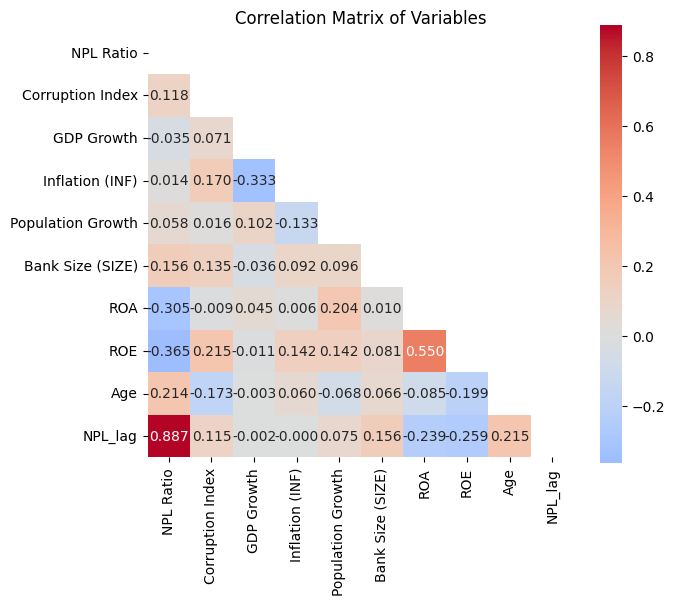

In [ ]:
plt.figure(figsize=(7, 6))
correlation_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.3f')
plt.title('Correlation Matrix of Variables')
plt.tight_layout()
plt.show()

Number of banks per country:
Country
India         14
Pakistan      14
Bangladesh    13
Sri Lanka     12
Nepal          6
Bhutan         4
Maldives       4
Name: Bank, dtype: int64


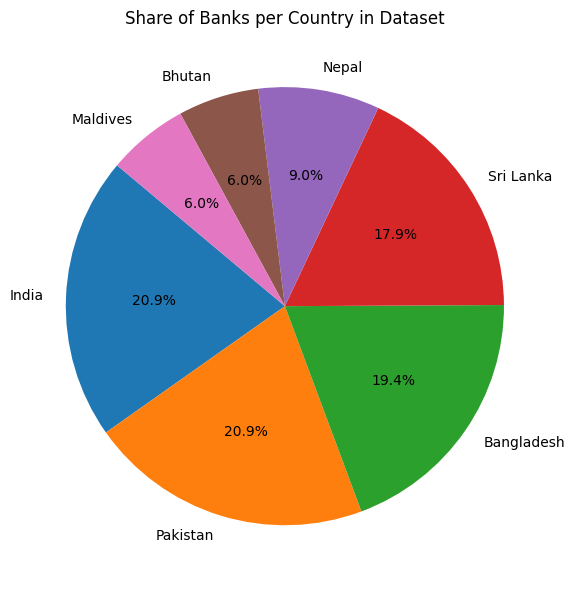

In [ ]:
df['Country'] = df['Country'].str.strip().str.title()
banks_per_country = df.groupby('Country')['Bank'].nunique().sort_values(ascending=False)

# Display the counts
print("Number of banks per country:")
print(banks_per_country)

# --- Step 2: Pie chart of country shares ---
plt.figure(figsize=(6,6))
plt.pie(
    banks_per_country,
    labels=banks_per_country.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Share of Banks per Country in Dataset")
plt.tight_layout()
plt.show()



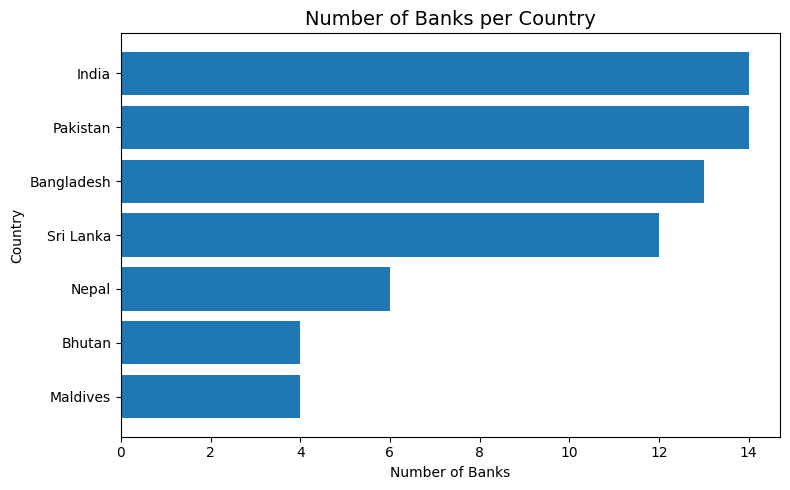

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(banks_per_country.index, banks_per_country.values)
plt.title("Number of Banks per Country", fontsize=14)
plt.xlabel("Number of Banks")
plt.ylabel("Country")
plt.gca().invert_yaxis()  # largest at top
plt.tight_layout()
plt.show()

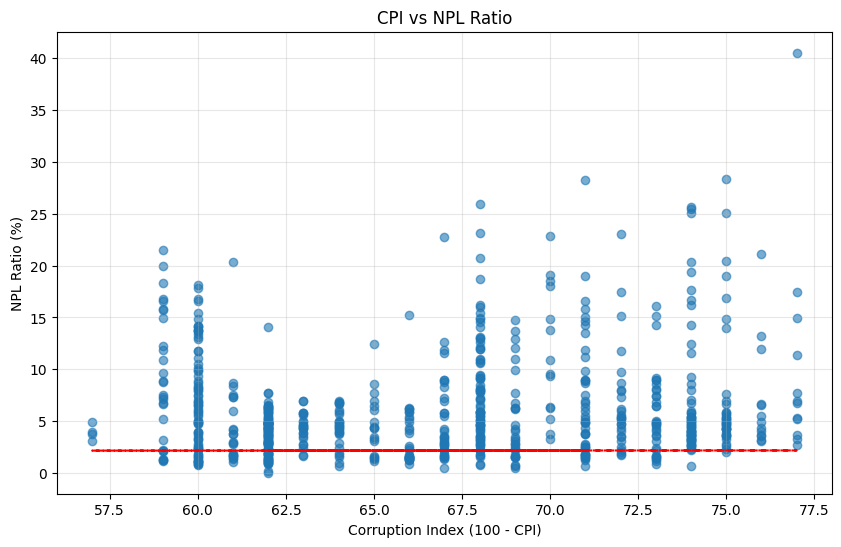

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Corruption Index'], df['NPL Ratio'], alpha=0.6)
plt.xlabel('Corruption Index (100 - CPI)')
plt.ylabel('NPL Ratio (%)')
plt.title('CPI vs NPL Ratio')
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['Corruption Index']**2, df['NPL Ratio'], 1)
p = np.poly1d(z)
plt.plot(df['Corruption Index'], p(df['Corruption Index']), "r--")
plt.show()

Text(0.5, 0, 'GDP Growth (%)')

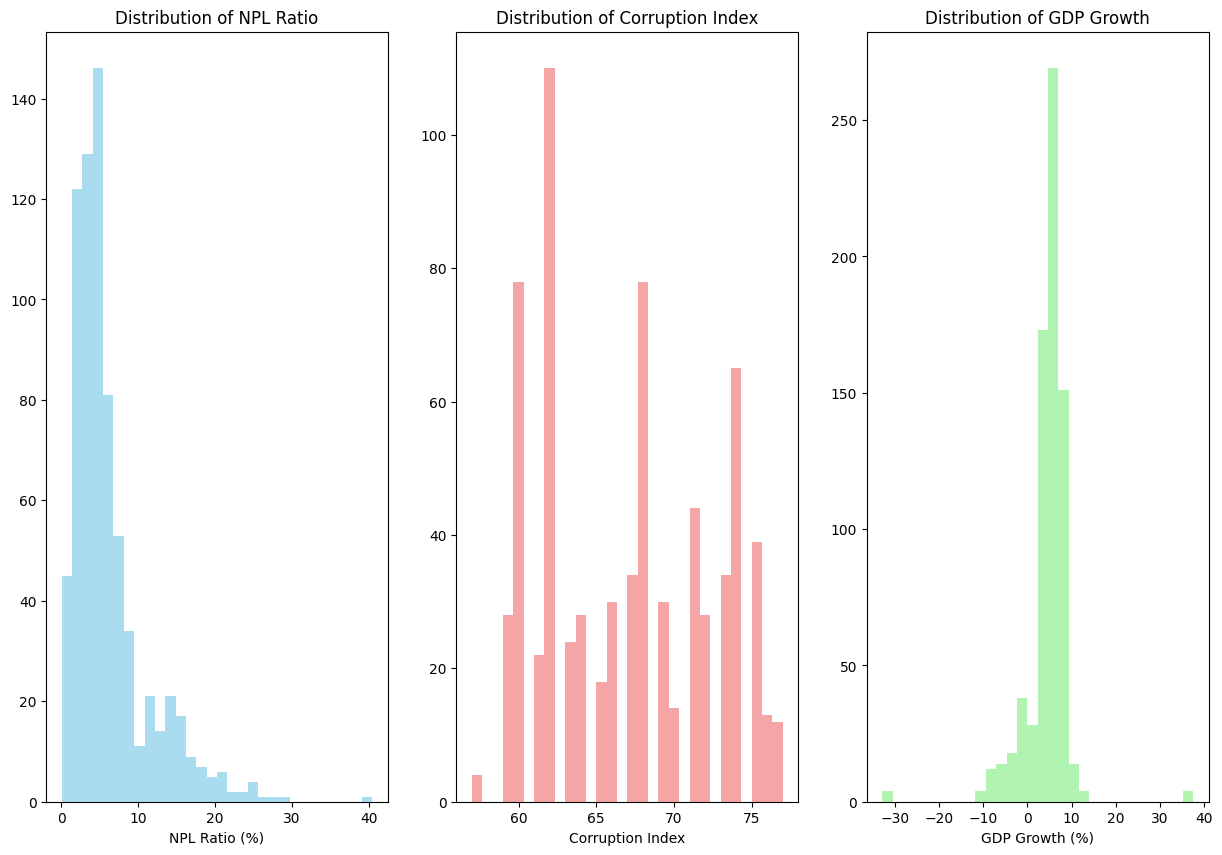

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

# NPL Distribution
axes[0].hist(df['NPL Ratio'], bins=30, alpha=0.7, color='skyblue')
axes[0].set_title('Distribution of NPL Ratio')
axes[0].set_xlabel('NPL Ratio (%)')

# Corruption Index Distribution
axes[1].hist(df['Corruption Index'], bins=30, alpha=0.7, color='lightcoral')
axes[1].set_title('Distribution of Corruption Index')
axes[1].set_xlabel('Corruption Index')

# GDP Growth Distribution
axes[2].hist(df['GDP Growth'], bins=30, alpha=0.7, color='lightgreen')
axes[2].set_title('Distribution of GDP Growth')
axes[2].set_xlabel('GDP Growth (%)')

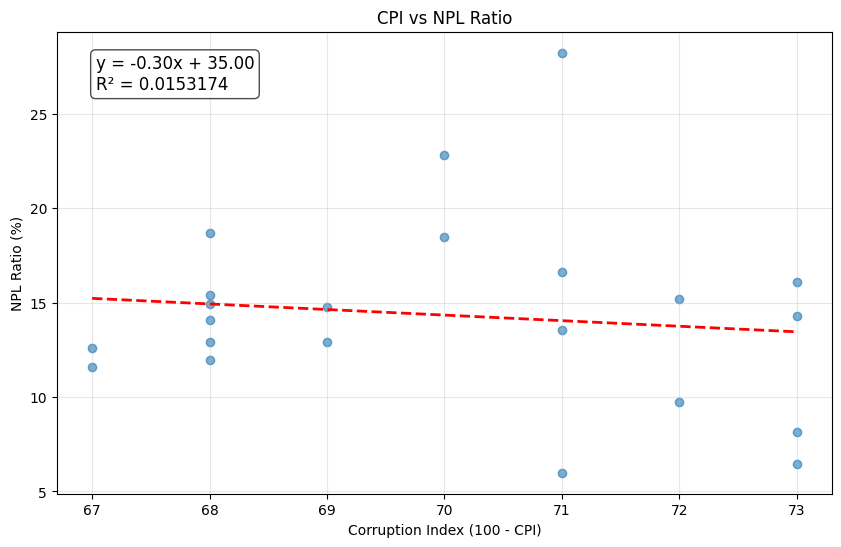

In [ ]:
# Drop NaN and non-numeric values
corr_with_npl = df[df['Bank_Type']=='Public']
corr_with_npl = corr_with_npl[corr_with_npl['Country']=='Pakistan']
x = pd.to_numeric(corr_with_npl['Corruption Index'], errors='coerce')
y = pd.to_numeric(corr_with_npl['NPL Ratio'], errors='coerce')

mask = (~x.isna()) & (~y.isna())
x = x[mask]
y = y[mask]

# Fit regression
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel('Corruption Index (100 - CPI)')
plt.ylabel('NPL Ratio (%)')
plt.title('CPI vs NPL Ratio')
plt.grid(True, alpha=0.3)

# Sorted line for smooth plot
x_sorted = np.sort(x)
plt.plot(x_sorted, p(x_sorted), "r--", linewidth=2)

# R² calculation
y_pred = p(x)
r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

# Equation + R²
equation_text = f"y = {z[0]:.2f}x + {z[1]:.2f}\nR² = {r2:.7f}"
plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.show()


In [ ]:
df_panel = df.set_index(['Bank', 'Year']).sort_index()
print("Panel dataset shape:", df_panel.shape)
print("Banks:", df_panel.index.get_level_values('Bank').nunique())
print("Years:", df_panel.index.get_level_values('Year').min(), "-", df_panel.index.get_level_values('Year').max())


Panel dataset shape: (733, 12)
Banks: 67
Years: 2014-01-01 00:00:00 - 2024-01-01 00:00:00


In [ ]:
num_vars  = df.select_dtypes(include=[np.number]).columns
desc = df_panel[num_vars].describe().T
desc['obs'] = df_panel[num_vars].count()
print("\nDescriptive Statistics:\n", desc[['mean','std','min','max','obs']])


Descriptive Statistics:
                         mean        std       min       max  obs
NPL Ratio           6.147181   5.043868   0.05000   40.4900  733
Corruption Index   66.953615   5.378873  57.00000   77.0000  733
GDP Growth          4.593753   5.284661 -32.90000   37.5000  733
Inflation (INF)     7.127912   7.204914  -1.60000   49.7211  733
Population Growth   1.082155   0.680844  -0.65132    3.5000  733
Bank Size (SIZE)   20.265986   5.254347   6.71000   27.4200  733
ROA                 1.225370   1.317553  -3.88000   22.2000  733
ROE                12.646848   9.811850 -51.53000   56.2700  733
Age                47.316508  38.232903   0.00000  170.0000  733
NPL_lag             6.258231   5.108787   0.05000   32.7700  733


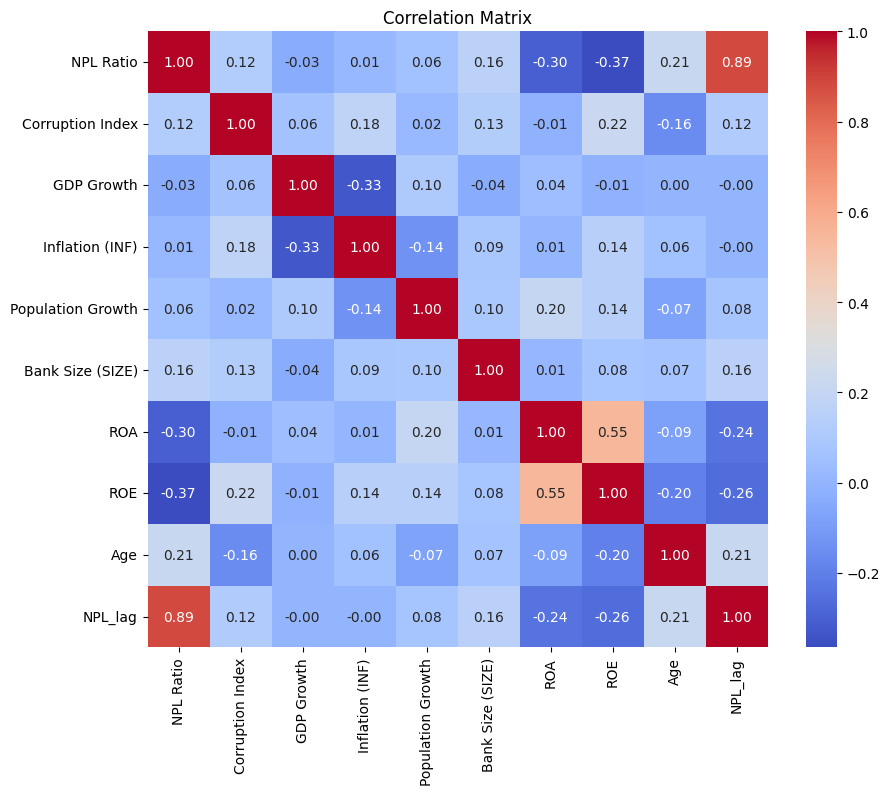

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_panel[num_vars].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corurelation Matrix")
plt.show()

In [ ]:
# --- 3. Multicollinearity (VIF) ---
vif_df = df_panel[num_vars].dropna()
vif_df_const = sm.add_constant(vif_df)
vif_data = pd.DataFrame({
    "feature": vif_df_const.columns,
    "VIF": [variance_inflation_factor(vif_df_const.values, i) for i in range(vif_df_const.shape[1])]
})
print("\nVIF Values:\n", vif_data)


VIF Values:
               feature         VIF
0               const  184.121433
1           NPL Ratio    5.342371
2    Corruption Index    1.211551
3          GDP Growth    1.161276
4     Inflation (INF)    1.231646
5   Population Growth    1.110692
6    Bank Size (SIZE)    1.071974
7                 ROA    1.537674
8                 ROE    1.809116
9                 Age    1.130719
10            NPL_lag    4.856110


In [ ]:
# --- 4. Fixed Effects Panel Regression (Initial Model) ---
# Dependent variable
y = df_panel['NPL Ratio']

# Independent variables (remove highly collinear ones if VIF > 10)
X_vars = ['Corruption Index', 'GDP Growth', 'Inflation (INF)',
          'Bank Size (SIZE)', 'ROA', 'NPL_lag','Bank_Type','Population Growth','Age']
X = df_panel[X_vars]
X = pd.get_dummies(X, columns=['Bank_Type'], drop_first=True)  # Encode Bank_Type
X = sm.add_constant(X)

In [ ]:
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True,drop_absorbed=True)
fe_results = fe_model.fit(cov_type='clustered', cluster_entity=True)
print("\n--- Fixed Effects Results ---")
print(fe_results.summary)


--- Fixed Effects Results ---
                          PanelOLS Estimation Summary                           
Dep. Variable:              NPL Ratio   R-squared:                        0.5127
Estimator:                   PanelOLS   R-squared (Between):             -1.5789
No. Observations:                 733   R-squared (Within):               0.5076
Date:                Wed, Oct 08 2025   R-squared (Overall):             -0.8665
Time:                        15:49:21   Log-likelihood                   -1566.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      85.218
Entities:                          67   P-value                           0.0000
Avg Obs:                       10.940   Distribution:                   F(8,648)
Min Obs:                      10.0000                                           
Max Obs:                       11.000   F-statistic (robust):             66.6

In [ ]:
# --- 5. Random Effects Model ---
re_model = RandomEffects(y, X)
re_results = re_model.fit()
print("\n--- Random Effects Results ---")
print(re_results.summary)


--- Random Effects Results ---
                        RandomEffects Estimation Summary                        
Dep. Variable:              NPL Ratio   R-squared:                        0.8004
Estimator:              RandomEffects   R-squared (Between):              0.9651
No. Observations:                 733   R-squared (Within):               0.4905
Date:                Wed, Oct 08 2025   R-squared (Overall):              0.8004
Time:                        15:49:56   Log-likelihood                   -1635.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      289.60
Entities:                          67   P-value                           0.0000
Avg Obs:                       10.940   Distribution:                  F(10,722)
Min Obs:                      10.0000                                           
Max Obs:                       11.000   F-statistic (robust):             289

In [ ]:
# --- 6. Hausman Test (FE vs RE) ---
from linearmodels.panel import compare
comparison = compare({'FE': fe_results, 'RE': re_results})
print("\n--- Hausman Test / FE vs RE ---")
print(comparison)


--- Hausman Test / FE vs RE ---
                    Model Comparison                   
                                   FE                RE
-------------------------------------------------------
Dep. Variable               NPL Ratio         NPL Ratio
Estimator                    PanelOLS     RandomEffects
No. Observations                  733               733
Cov. Est.                   Clustered        Unadjusted
R-squared                      0.5127            0.8004
R-Squared (Within)             0.5076            0.4905
R-Squared (Between)           -1.5789            0.9651
R-Squared (Overall)           -0.8665            0.8004
F-statistic                    85.218            289.60
P-value (F-stat)               0.0000            0.0000
=====================     ===========   ===============
const                          6.6651           -2.2652
                             (1.8053)         (-1.8127)
Corruption Index               0.0372            0.0454
               

In [ ]:
import numpy as np

# Get coefficient vectors and covariance matrices
b_FE = fe_results.params.values
b_RE = re_results.params.values

V_FE = fe_results.cov.values
V_RE = re_results.cov.values

# Only compare common variables (exclude dummies if needed)
common_idx = [i for i, name in enumerate(fe_results.params.index) if name in re_results.params.index]

b_diff = b_FE[common_idx] - b_RE[common_idx]
V_diff = V_FE[np.ix_(common_idx, common_idx)] - V_RE[np.ix_(common_idx, common_idx)]

# Hausman statistic
from scipy.stats import chi2
stat = b_diff.T @ np.linalg.inv(V_diff) @ b_diff
df_ = len(b_diff)
p_value = 1 - chi2.cdf(stat, df_)

print(f"Hausman test chi2 = {stat:.4f}, df = {df_}, p-value = {p_value:.4f}")


Hausman test chi2 = 22.4705, df = 9, p-value = 0.0075


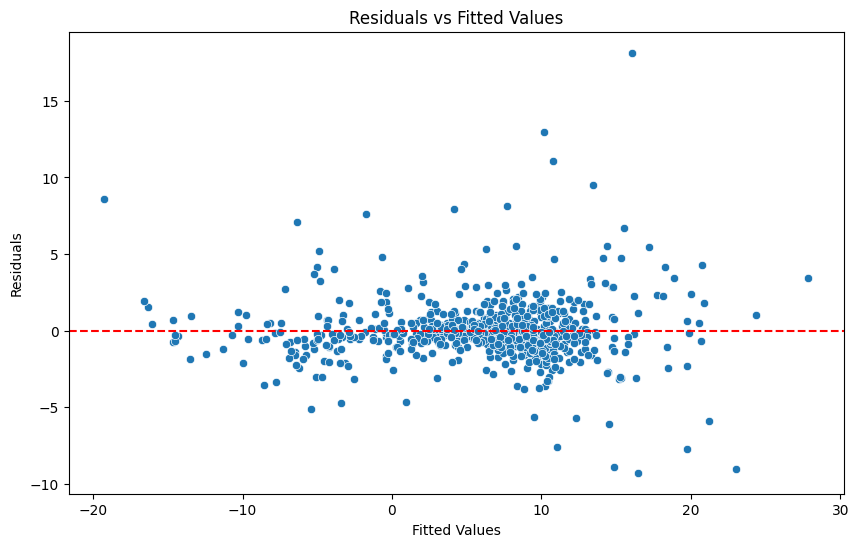

In [ ]:
# --- 7. Residual Diagnostics ---
# Convert to 1D
residuals = fe_results.resids.squeeze()   # or .values.flatten()
fitted = fe_results.fitted_values.squeeze()

# Now plotting works
plt.figure(figsize=(10,6))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()


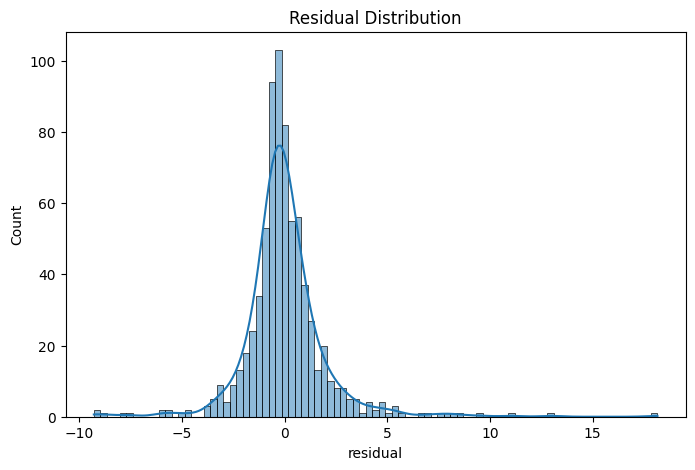

In [ ]:
# Histogram of residuals
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

In [ ]:
# Import the necessary library if not already done
from linearmodels.panel import RandomEffects
import statsmodels.api as sm

# --- Preparing your data (as you did before) ---
# Ensure df_panel is set up with 'Bank' and 'Year' as the index
df_panel = df.set_index(['Bank', 'Year']).sort_index()

# Define dependent and independent variables
y = df_panel['NPL Ratio']
X_vars = ['Corruption Index', 'GDP Growth', 'Inflation (INF)',
          'Bank Size (SIZE)', 'ROA', 'NPL_lag','Bank_Type']
X = df_panel[X_vars]
X = pd.get_dummies(X, columns=['Bank_Type'], drop_first=True)
X = sm.add_constant(X) # Add the constant

# --- Running the Final Robust RE Model ---
# Note: linearmodels automatically handles entity effects for RE
re_model_robust = RandomEffects(y, X)

# Fit the model with standard errors clustered by the entity ('Bank')
re_results_robust = re_model_robust.fit(cov_type='clustered', cluster_entity=True)

# Print the new, robust summary
print("--- Robust Random Effects Results ---")
print(re_results_robust.summary)

--- Robust Random Effects Results ---
                        RandomEffects Estimation Summary                        
Dep. Variable:              NPL Ratio   R-squared:                        0.7993
Estimator:              RandomEffects   R-squared (Between):              0.9653
No. Observations:                 733   R-squared (Within):               0.4869
Date:                Wed, Oct 08 2025   R-squared (Overall):              0.7993
Time:                        16:05:06   Log-likelihood                   -1637.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      360.51
Entities:                          67   P-value                           0.0000
Avg Obs:                       10.940   Distribution:                   F(8,724)
Min Obs:                      10.0000                                           
Max Obs:                       11.000   F-statistic (robust):          

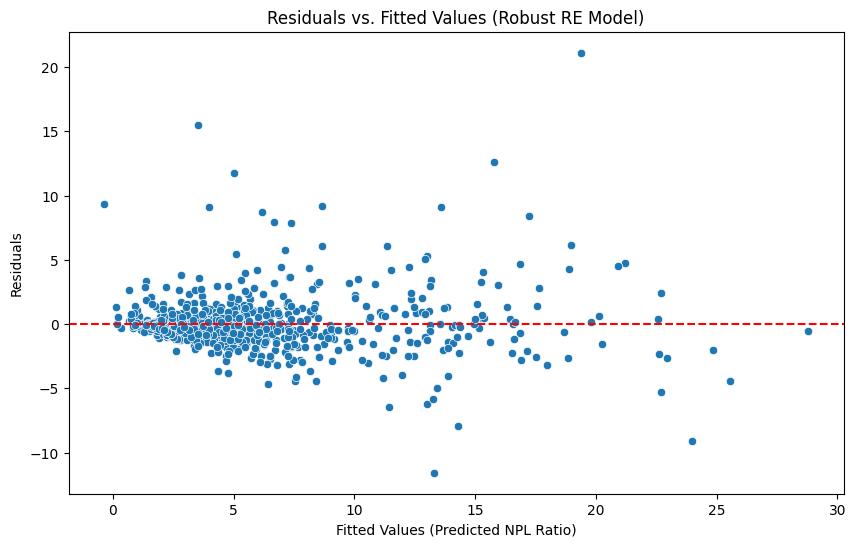

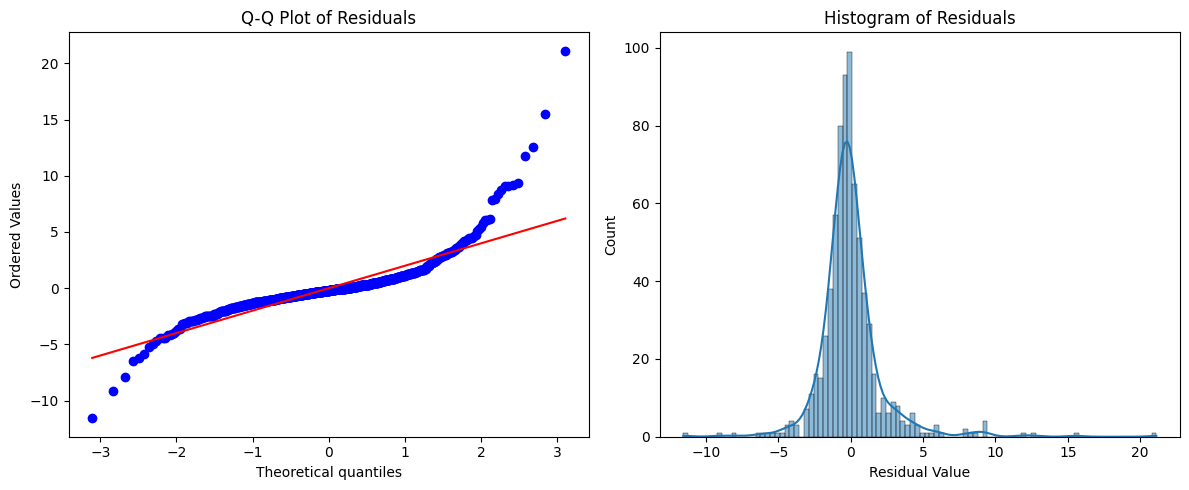

In [ ]:
# First, get the residuals and fitted values from your robust RE model
residuals = re_results_robust.resids.squeeze()
fitted_values = re_results_robust.fitted_values.squeeze()

# --- a) Visual Check for Heteroscedasticity (Residuals vs. Fitted) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values (Robust RE Model)')
plt.xlabel('Fitted Values (Predicted NPL Ratio)')
plt.ylabel('Residuals')
plt.show()

# --- b) Normality of Residuals (Q-Q Plot and Histogram) ---
import scipy.stats as stats

# Q-Q Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st subplot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')

# Histogram
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd subplot
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# --- Step 1: Calculate Standardized Residuals ---
# Use the residuals from your robust RE model
residuals = re_results_robust.resids.squeeze()

# Calculate the standard deviation of the residuals, ignoring NaN values
resid_std = np.nanstd(residuals)

# Standardize the residuals by dividing by their standard deviation
standardized_residuals = residuals / resid_std

# --- Step 2: Identify and Display Outliers ---
# Define your threshold for what constitutes an outlier
outlier_threshold = 2.5

# Find the outliers where the absolute standardized residual is above the threshold
outliers = df_panel[np.abs(standardized_residuals) > outlier_threshold]

# --- Step 3: Display the Results ---
# Add the residual information to the outlier dataframe for context
outliers_with_info = outliers.copy()
outliers_with_info['residual'] = residuals[outliers.index]
outliers_with_info['standardized_residual'] = standardized_residuals[outliers.index]

print(f"--- Found {len(outliers_with_info)} Outliers (Threshold > {outlier_threshold}) ---")
# Display the outliers, sorted by the magnitude of their error
print(outliers_with_info.sort_values(by='standardized_residual', ascending=False))

--- Found 22 Outliers (Threshold > 2.5) ---
                                                  Country  NPL Ratio  \
Bank                               Year                                
Agrani Bank PLC                    2024-01-01  Bangladesh      40.49   
BankIslami                         2015-01-01    Pakistan      19.04   
Agrani Bank PLC                    2022-01-01  Bangladesh      28.37   
Yes Bank                           2020-01-01       India      16.80   
Standard Chartered Bank (Pakistan) 2022-01-01    Pakistan       9.00   
Central Bank of India              2017-01-01       India      17.81   
Bhutan Development Bank            2017-01-01      Bhutan      22.72   
Bank of India                      2016-01-01       India      13.07   
United Commercial Bank PLC (UCB)   2024-01-01  Bangladesh      14.90   
Agrani Bank PLC                    2016-01-01  Bangladesh      25.59   
Bhutan Development Bank            2023-01-01      Bhutan      14.60   
DFCC Bank           

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- Step 1: Define the corrected model formula ---
# We use Q("...") to handle column names with spaces or special characters.
# 'C(Bank)' creates dummy variables for each bank to mimic fixed effects.
formula = """
Q("NPL Ratio") ~ NPL_lag + ROA + Q("GDP Growth") +
                 Q("Corruption Index") + Q("Inflation (INF)") + Q("Bank Size (SIZE)") + C(Bank_Type)
"""

# --- Step 2: Fit the Robust Linear Model (RLM) ---
# This uses the original 'df' dataframe
robust_model = smf.rlm(formula=formula, data=df, M=sm.robust.norms.HuberT())
robust_results = robust_model.fit()

# --- Step 3: Print the summary for the variables of interest ---
# The full summary is long due to the bank dummies, so we select the main variables.
print("--- Robust Regression (RLM) Results ---")
print(robust_results.summary(
))

--- Robust Regression (RLM) Results ---
                    Robust linear Model Regression Results                    
Dep. Variable:         Q("NPL Ratio")   No. Observations:                  733
Model:                            RLM   Df Residuals:                      724
Method:                          IRLS   Df Model:                            8
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Wed, 08 Oct 2025                                         
Time:                        16:06:11                                         
No. Iterations:                    28                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [ ]:
from linearmodels.iv import IV2SLS
import statsmodels.api as sm

# --- Step 1: Prepare the data and create the instrument ---
iv_data = df_panel.dropna(subset=['NPL Ratio', 'NPL_lag', 'ROA', 'GDP Growth'])
iv_data['NPL_t2'] = iv_data.groupby('Bank')['NPL_lag'].shift(1)
iv_data = iv_data.dropna()

# --- Step 2: Define the variables for the IV model ---
dependent = iv_data['NPL Ratio']
exog = sm.add_constant(iv_data[['ROA', 'GDP Growth']])
endog = iv_data[['NPL_lag']]
instruments = iv_data[['NPL_t2']]

# --- Step 3: Fit the IV model ---
iv_model = IV2SLS(dependent, exog, endog, instruments)

# CORRECTED LINE: Use the 'clusters' argument to specify the clustering variable
iv_results = iv_model.fit(cov_type='clustered', clusters=iv_data.index.get_level_values('Bank'))

# --- Step 4: Print the results ---
print("--- Instrumental Variable (2SLS) Regression Results ---")
print(iv_results)

--- Instrumental Variable (2SLS) Regression Results ---
                          IV-2SLS Estimation Summary                          
Dep. Variable:              NPL Ratio   R-squared:                      0.7785
Estimator:                    IV-2SLS   Adj. R-squared:                 0.7775
No. Observations:                 666   F-statistic:                    413.62
Date:                Wed, Oct 08 2025   P-value (F-stat)                0.0000
Time:                        16:06:18   Distribution:                  chi2(3)
Cov. Estimator:             clustered                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          1.4813     0.4528     3.2711     0.0011      0.5937      2.3

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- Step 1: Create the Subsample DataFrames ---
# Make sure to use the exact string for the bank types as it appears in your 'Bank_Type' column.
# Common values are 'Public' and 'Private'.
df_public = df[df['Bank_Type'] == 'Public'].copy()
df_private = df[df['Bank_Type'] == 'Private'].copy()

print(f"--- Analysis for Public Banks ({len(df_public)} observations) ---")

# --- Step 2: Run the RLM for Public Banks ---
# Define the same model formula as before
formula = """
Q("NPL Ratio") ~ NPL_lag + ROA + Q("GDP Growth") + Q("Corruption Index") +
                 Q("Inflation (INF)") + Q("Bank Size (SIZE)") + C(Bank)
"""

# Fit the RLM on the public banks data
rlm_public = smf.rlm(formula=formula, data=df_public, M=sm.robust.norms.HuberT())
results_public = rlm_public.fit()

# Print the summary for the public banks model
print(results_public.summary(
))

print("\n" + "="*80 + "\n")

print(f"--- Analysis for Private Banks ({len(df_private)} observations) ---")

# --- Step 3: Run the RLM for Private Banks ---
# Fit the RLM on the private banks data using the same formula
rlm_private = smf.rlm(formula=formula, data=df_private, M=sm.robust.norms.HuberT())
results_private = rlm_private.fit()

# Print the summary for the private banks model
print(results_private.summary(

))

--- Analysis for Public Banks (317 observations) ---
                    Robust linear Model Regression Results                    
Dep. Variable:         Q("NPL Ratio")   No. Observations:                  317
Model:                            RLM   Df Residuals:                      282
Method:                          IRLS   Df Model:                           34
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Wed, 08 Oct 2025                                         
Time:                        16:10:00                                         
No. Iterations:                    50                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------

In [ ]:
# --- 1. Data Loading and Preparation ---

# Load all sheets from the Excel file

df_dict = pd.read_excel("/content/RM project - Credit Risk (1).xlsx", sheet_name=None)

# Get all sheet names and exclude the last one

sheet_names = list(df_dict.keys())

sheet_names_to_merge = sheet_names[:-2]

# Read and combine the relevant sheets

df = pd.concat([df_dict[name] for name in sheet_names_to_merge], ignore_index=True)

df = df.drop('COC', axis=1)
# Convert 'Year' to datetime objects and sort

df['Year'] = pd.to_datetime(df['Year'], format='%Y')

df = df.sort_values(by=['Bank', 'Year'])


--- Data prepared for Machine Learning analysis. ---
Train set size: 485, Test set size: 97
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...

--- Model Evaluation Results ---
Decision Tree: R-squared = 0.5126, RMSE = 2.9078
Random Forest: R-squared = 0.6995, RMSE = 2.2829
Gradient Boosting: R-squared = 0.6907, RMSE = 2.3162
XGBoost: R-squared = 0.7213, RMSE = 2.1987


<Figure size 1200x800 with 0 Axes>

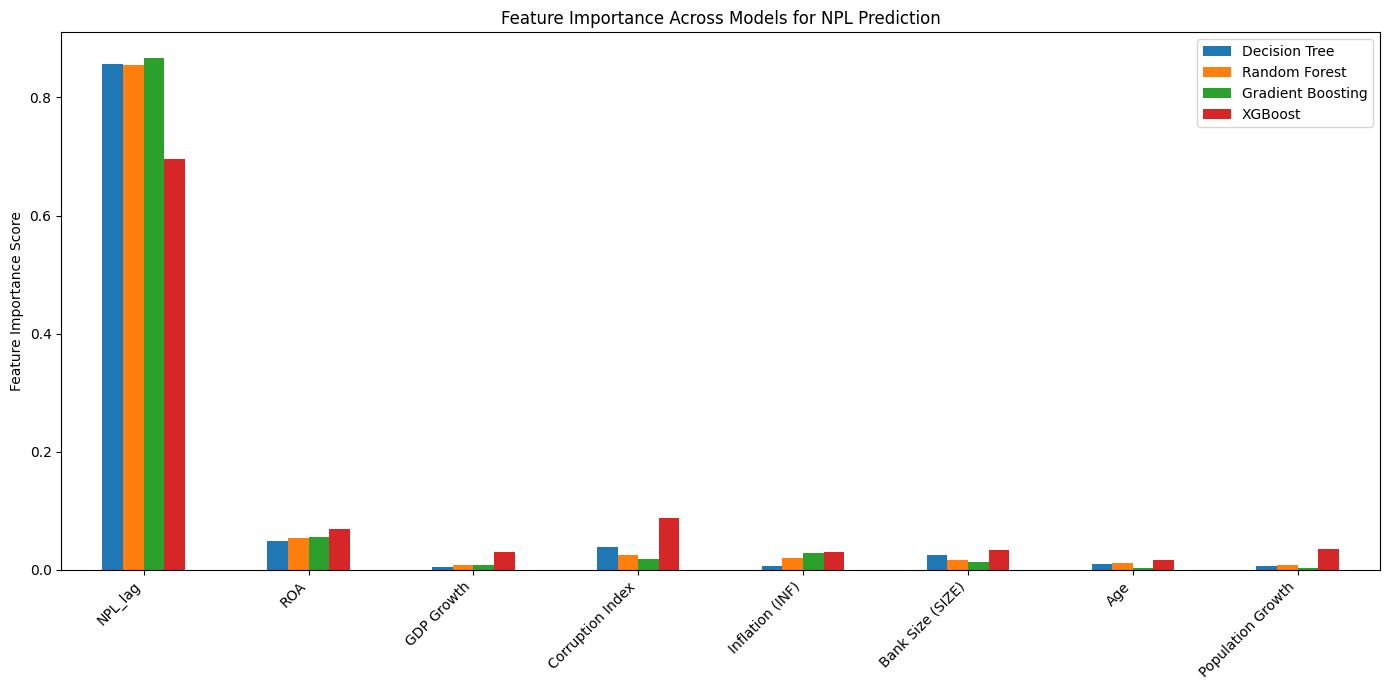

In [ ]:


from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import xgboost as xgb

from sklearn.metrics import r2_score, mean_squared_error




# Drop rows with missing values to ensure all models run smoothly

df_ml = df.dropna().reset_index(drop=True)



print("--- Data prepared for Machine Learning analysis. ---")



# --- 2. Feature Selection and Data Split ---

# Define predictor variables (features) and the target variable

features = ['NPL_lag', 'ROA', 'GDP Growth', 'Corruption Index',

            'Inflation (INF)', 'Bank Size (SIZE)', 'Age', 'Population Growth']

target = 'NPL Ratio'



X = df_ml[features]

y = df_ml[target]



# We will use a TimeSeriesSplit to respect the temporal nature of the data

# This ensures we train on past data and test on more recent data

tscv = TimeSeriesSplit(n_splits=5)

# Using the last split for a final train/test evaluation

for train_index, test_index in tscv.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]

    y_train, y_test = y.iloc[train_index], y.iloc[test_index]



print(f"Train set size: {len(X_train)}, Test set size: {len(X_test)}")



# --- 3. Define and Train Machine Learning Models ---

# Initialize the models

dt = DecisionTreeRegressor(random_state=42)

rf = RandomForestRegressor(random_state=42)

gb = GradientBoostingRegressor(random_state=42)

xg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)



models = {

    'Decision Tree': dt,

    'Random Forest': rf,

    'Gradient Boosting': gb,

    'XGBoost': xg

}



# Train each model

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)



# --- 4. Evaluate Models and Feature Importance ---

results = {}

feature_importances = {}



print("\n--- Model Evaluation Results ---")

for name, model in models.items():

    # Make predictions on the test set

    y_pred = model.predict(X_test)



    # Calculate performance metrics

    r2 = r2_score(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))



    results[name] = {'R-squared': r2, 'RMSE': rmse}

    print(f"{name}: R-squared = {r2:.4f}, RMSE = {rmse:.4f}")



    # Store feature importances

    if hasattr(model, 'feature_importances_'):

        feature_importances[name] = model.feature_importances_



# --- 5. Visualize Feature Importance ---

# Create a DataFrame for plotting

importance_df = pd.DataFrame(feature_importances, index=features)



# Plotting

plt.figure(figsize=(12, 8))

importance_df.plot(kind='bar', figsize=(14, 7))

plt.title('Feature Importance Across Models for NPL Prediction')

plt.ylabel('Feature Importance Score')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# Convert 'Year' to datetime objects and sort chronologically
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df = df.sort_values(by='Year')
# Drop rows with missing values to ensure all models run smoothly
df_ml = df.dropna().reset_index(drop=True)

print("--- Data prepared for Machine Learning analysis. ---")

# --- 2. Feature Selection ---
features = ['NPL_lag', 'ROA', 'GDP Growth', 'Corruption Index',
            'Inflation (INF)', 'Bank Size (SIZE)', 'Age', 'Population Growth']
target = 'NPL Ratio'

X = df_ml[features]
y = df_ml[target]

# --- 3. Define Models and Splits ---
models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
}

split_ratios = [0.7, 0.6]  # Corresponds to 70/30 and 60/40 splits
all_results = []

# --- 4. Loop Through Splits and Models to Evaluate ---
for ratio in split_ratios:
    split_label = f"{int(ratio*100)}:{int((1-ratio)*100)}"
    print(f"\n--- Evaluating for {split_label} Train/Test Split ---")

    # Create the time-based train/test split
    train_size = int(len(X) * ratio)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    for name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)

        # Make predictions
        y_pred = model.predict(X_test)

        # Calculate performance metrics
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)

        # Store results
        all_results.append({
            'Model': name,
            'Train/Test Split': split_label,
            'R2': r2,
            'RMSE': rmse,
            'MAE': mae
        })

# --- 5. Display Final Results Table ---
results_df = pd.DataFrame(all_results)
print("\n--- Final Algorithms Evaluation Table ---")
print(results_df)

--- Data prepared for Machine Learning analysis. ---

--- Evaluating for 70:30 Train/Test Split ---

--- Evaluating for 60:40 Train/Test Split ---

--- Final Algorithms Evaluation Table ---
               Model Train/Test Split        R2      RMSE       MAE
0      Decision Tree            70:30  0.459071  3.562856  2.275486
1      Random Forest            70:30  0.641394  2.900928  1.730087
2  Gradient Boosting            70:30  0.659377  2.827253  1.676112
3            XGBoost            70:30  0.633511  2.932637  1.775959
4      Decision Tree            60:40  0.523855  3.240615  2.216052
5      Random Forest            60:40  0.669258  2.700863  1.653656
6  Gradient Boosting            60:40  0.646604  2.791827  1.748374
7            XGBoost            60:40  0.666652  2.711485  1.655089


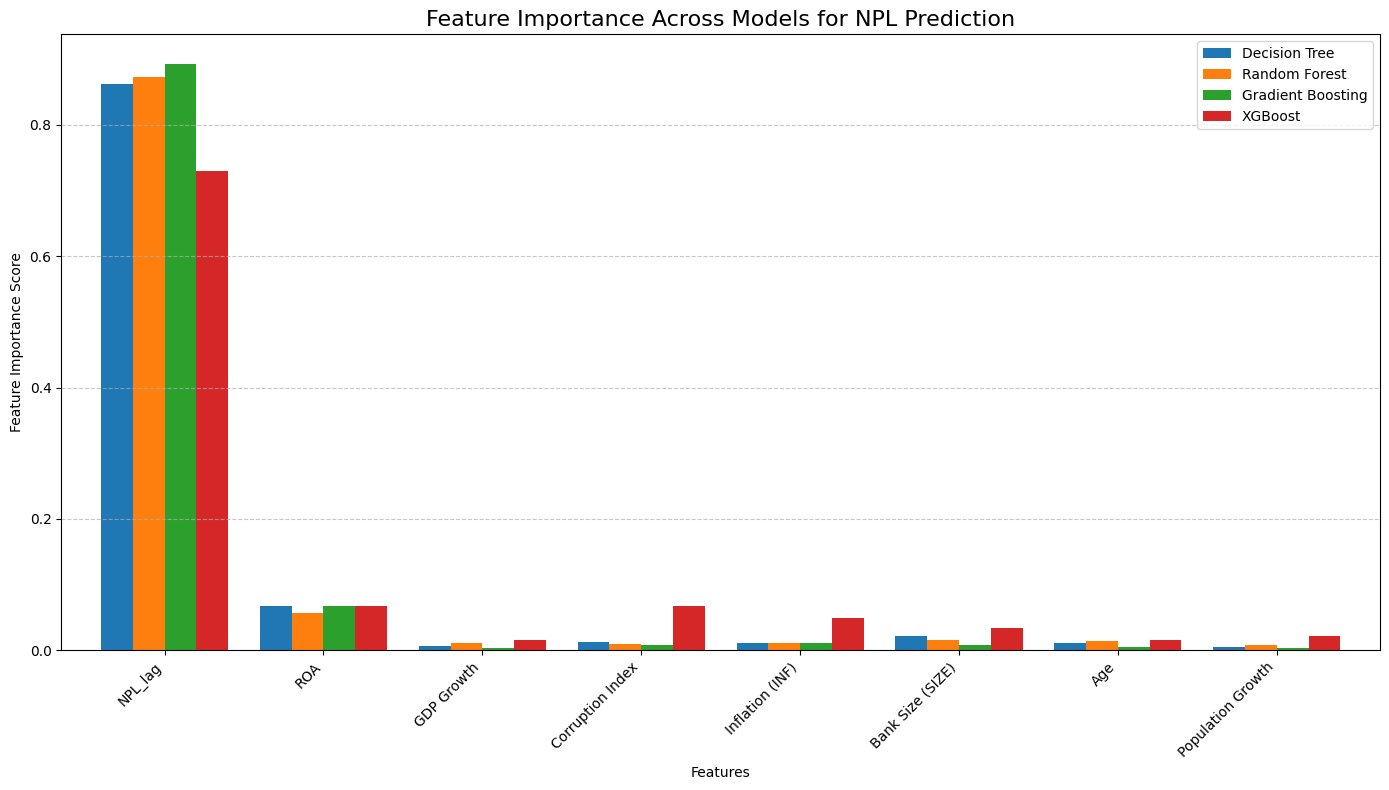

In [ ]:
# --- 1. Extract Feature Importances ---
feature_importances = {}
for name, model in models.items():
    # Only ensemble models and decision trees have this attribute
    if hasattr(model, 'feature_importances_'):
        feature_importances[name] = model.feature_importances_

# --- 2. Create a DataFrame for Easy Plotting ---
importance_df = pd.DataFrame(feature_importances, index=features)

# --- 3. Generate the Bar Plot ---
# This will create a grouped bar chart, with one bar per model for each feature
importance_df.plot(kind='bar', figsize=(14, 8), width=0.8)

plt.title('Feature Importance Across Models for NPL Prediction', fontsize=16)
plt.ylabel('Feature Importance Score')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
